In [1]:
!nvidia-smi

Sun Sep 28 08:30:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Задание

1. Подготовить датасет для обучения модели сегментации дефектов на стали. Для этого нужно:
    - Заполнить класс SeverstalSteelDataset в hw2_template.ipynb:
        - Реализовать метод __len__ для возвращения размера датасета
        - Реализовать метод __getitem__ для возвращения изображения и маски дефекта по индексу в виде тензоров
    - Реализовать функцию для разделения датасета на train и val
    - Создать DataLoader для train, val, test датасетов
2. Реализовать класс модели сегментации SegModel в hw2_template.ipynb.
    - Он может использовать как предобученные модели из torchvision, segmentation_models_pytorch, так и свою архитектуру.
3. Обучить модель на датасете Severstal: Steel Defect Detection.
4. Предсказать дефекты на тестовом датасете и сохранить результат в виде масок изображений перобразовнных в формат EncodedPixels.
5. Задание сдается в виде Jupyter Notebook/Google Colab ноутбука с кодом и submission.csv файла.

В качестве метрики качества будем использовать Dice score (IoU) для каждого класса дефекта и среднее значение по всем классам.

Чтобы получить 9 баллов, достаточно продемонстрировать средний по классам Dice score = 0.80 на данных из val.csv в ноутбуке.

Чтобы получить 10 баллов, нужно загрузить решение на Kaggle и набрать score > 0.85.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


In [3]:
!pip install lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 50.9 MB/s eta 0:00:00


In [4]:
!pip install -q segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00


In [5]:


def encoded_pixels_to_masks(fname: str, df: pd.DataFrame):
    fname_df = df[df['ImageId'] == fname] #получаем fname, фильтр train.csv для одного изображения
    masks = np.zeros((256 * 1600, 4), dtype=np.float32) # float32 is V.Imp формирование маски

    for i_row, row in fname_df.iterrows(): #перебор строк с названием файла
        cls_id = row['ClassId']
        encoded_pixels = row['EncodedPixels']
        if pd.notna(encoded_pixels):
            pixel_list = list(map(int, encoded_pixels.split(' ')))# преобразование маски
            for i in range(0, len(pixel_list), 2):
                start_pixel = pixel_list[i] - 1
                num_pixel = pixel_list[i+1]
                masks[start_pixel:(start_pixel+num_pixel), cls_id-1] = 1

    masks = masks.reshape(256, 1600, 4, order='F')  #нумерация пикселей идет по столбцам
    masks = masks.transpose(2,0,1)
    return masks

def masks_to_encoded_pixels(masks: np.ndarray):
    print(masks.size())
    encoded_pixels_list = []
    for cls_mask in masks:
        pixels = cls_mask.T.flatten() #можно так: flatten(order='F')

        rle = []
        i = 0
        while i < len(pixels):
            if pixels[i] == 1:
                start = i + 1
                length = 1
                i += 1
                while i < len(pixels) and pixels[i] == 1:
                    length += 1
                    i += 1
                rle.extend([start, length])
            else:
                i += 1
        encoded_pixels_list.append(' '.join(map(str, rle)) if len(rle) > 0 else '')

    return encoded_pixels_list

In [6]:
from PIL import Image
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=90, p=0.5),
    A.Resize(256, 512),
    A.Normalize(mean=(0.3446,), std=(0.2054,)),
    ToTensorV2()
])
class SeverstalSteelDataset(Dataset):
    def __init__(self, fnames, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.fnames = fnames
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        fname = self.fnames[idx] #по индексу получает fname
        img_path = os.path.join(self.img_dir, fname)

        img = Image.open(img_path).convert('L') #конвертирует в чб
        img = np.array(img, dtype=np.float32)



        masks = encoded_pixels_to_masks(fname, self.df)

        if self.transform:
            img_hwc = np.expand_dims(img, axis=-1)
            masks_hwc = masks.transpose(1,2,0)

            augmented = self.transform(image=img_hwc, mask=masks_hwc)
            img = augmented['image']
            masks = augmented['mask']


            if isinstance(masks, torch.Tensor):
                masks = masks.permute(2,0,1).float()

        else:

            mean, std = 0.3446, 0.2054 #значения датасета
            img = (img / 255.0 - mean) / std
            img = torch.from_numpy(img).unsqueeze(0).float()
            masks = torch.from_numpy(masks).float()
        return fname, img, masks

def collate_fn(batch_items):
    batched_fnames = [item[0] for item in batch_items]
    batched_imgs = torch.stack([item[1] for item in batch_items])
    batched_masks = torch.stack([item[2] for item in batch_items]) #объединяем тензоры в батч
    return batched_fnames, batched_imgs, batched_masks


In [7]:
import segmentation_models_pytorch as smp

class SegModel(torch.nn.Module):
    def __init__(self):
        super(SegModel, self).__init__()
        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=1,
            classes=4)

    def forward(self, x):
        return self.model(x)

In [8]:
from sklearn.model_selection import train_test_split

def load_data(train_val_csv, test_csv, train_val_img_dir, test_img_dir, batch_size, val_size):
    train_val_df = pd.read_csv(train_val_csv)
    train_val_fnames = pd.unique(train_val_df.ImageId)
    # print(len(train_val_fnames))
    test_df = pd.read_csv(test_csv)
    test_fnames = pd.unique(test_df.ImageId)


    train_fnames, val_fnames = train_test_split(train_val_fnames, test_size=val_size, random_state=42)

    # masks_dir = '/content/drive/MyDrive/HW2_ML/precomputed_masks'

    train_dataset = SeverstalSteelDataset(train_fnames, train_val_df, train_val_img_dir, transform=None)

    val_dataset = SeverstalSteelDataset(val_fnames, train_val_df, train_val_img_dir,transform=None)

    test_dataset = SeverstalSteelDataset(test_fnames, test_df, test_img_dir,transform=None)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return train_loader, val_loader, test_loader


In [9]:
import logging

logging.basicConfig(
    filename=os.path.join('/content/drive/MyDrive/HW2_ML','training_tmp.log'),
    filemode='w',
    format='%(asctime)s - %(levelname)s - %(message)s',
    level=logging.INFO
)
console = logging.StreamHandler()
console.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
console.setFormatter(formatter)
logging.getLogger().addHandler(console)



In [17]:
import torch.optim as optim
import torch.nn as nn
import os, shutil
import copy

bce = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode='multilabel', from_logits=True)

def func_criterion(x, y):
  alpha = 0.5
  loss = alpha * bce(x, y) + (1-alpha) * dice(x, y)
  return loss

def init_model(lr = 0.001):
    model = SegModel()
    criterion = func_criterion
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, criterion, optimizer

def train(model = None, criterion= None, optimizer= None, train_loader= None,
          test_loader= None, val_loader= None, test_csv= None, epochs= None, device='cuda', r_s = None):
    model.load_state_dict(torch.load('/content/drive/MyDrive/HW2_ML/weight/model_epoch4_40.pth', map_location=device))
    best_state = None
    best_val_dice = 0.0

    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss_total = 0.0
        running_loss = 0.0
        running_samples = 0

        for i, (fnames, X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)
            train_loss_total += loss.item() * batch_size
            running_loss += loss.item() * batch_size
            running_samples += batch_size

            # среднмий loss каждые 100 батчей
            if (i + 1) % 100 == 0:
                avg_loss = running_loss / running_samples
                logging.info(f'Epoch {epoch+1}, Batch {i+1}, Avg Train Loss (last 100 batches): {avg_loss:.4f}')
                print(f'Epoch {epoch+1}, Batch {i+1}, Avg Train Loss (last 100 batches): {avg_loss:.4f}')
                running_loss = 0.0
                running_samples = 0

        # Средний train loss по всей эпохе
        train_loss_epoch = train_loss_total / len(train_loader.dataset)

        # Валидация
        model.eval()
        val_dice_total = 0.0
        num_samples = 0
        for _, X_val, y_val in val_loader:
            _, _, mean_dice, hard_dice_mean_per_class = evaluate(model, X_val, y_val, device=device)
            batch_size = X_val.size(0)
            val_dice_total += mean_dice * batch_size
            num_samples += batch_size
        val_dice_epoch = val_dice_total / num_samples

        # Сохранение весов каждой эпохи
        weights_file = os.path.join('/content/drive/MyDrive/HW2_ML', f'model_epoch{epoch+1}_{r_s}_{val_dice_epoch:.4f}.pth')
        torch.save(model.state_dict(), weights_file)

        # Сохраняем лучшие веса отдельно
        if val_dice_epoch > best_val_dice:
            best_val_dice = val_dice_epoch
            best_state = copy.deepcopy(model.state_dict())

        logging.info(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_epoch:.4f}, Val Mean Dice: {val_dice_epoch:.4f}')
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_epoch:.4f}, Val Mean Dice: {val_dice_epoch:.4f}')


    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_dice

# Надеюсь, что  метрика идеальна)
def evaluate(model, X, y=None, device='cuda', threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device))
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

    if y is None:
        return preds.cpu(), None, None, None


    y_true = y.to(device).float()
    eps = 1e-7
    intersection = (preds * y_true).sum(dim=(2, 3))
    cardinality  = preds.sum(dim=(2, 3)) + y_true.sum(dim=(2, 3))
    hard_dice_per_sample_class = (2 * intersection + eps) / (cardinality + eps)
    # В самом конце для hard усредняем по батчам и по классам
    hard_dice_mean = hard_dice_per_sample_class.mean().item()
    hard_dice_mean_per_class = hard_dice_per_sample_class.mean(dim=0)
    return preds.cpu(), None, hard_dice_mean, hard_dice_mean_per_class

def test_prediction(test_loader = None, train_model= None,
                    val_dice= None, ep= None, test_csv= None, r_s= None):

    threshold = 0.5
    torch.manual_seed(r_s)
    np.random.seed(r_s)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    train_model.eval()
    all_preds = []

    with torch.no_grad():
        for fnames, X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            logits = train_model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()


    submission_rows = []
    test_df = pd.read_csv(test_csv)
    unique_fnames = pd.unique(test_df.ImageId)

    for i, fname in enumerate(unique_fnames):
        masks = all_preds[i]
        encoded_pixels_list = masks_to_encoded_pixels(masks)
        for cls_id, enc_str in enumerate(encoded_pixels_list, start=1):
            submission_rows.append({'ImageId': fname, 'ClassId': cls_id, 'EncodedPixels': enc_str})

    submission_out = pd.DataFrame(submission_rows, columns=['ImageId', 'ClassId', 'EncodedPixels'])
    submission_path = os.path.join('/content/drive/MyDrive/HW2_ML', f'submission_{val_dice:.4f}_{r_s}_num_epoch_{ep}.csv')
    submission_out.to_csv(submission_path, index=False)




In [7]:
'EVQLLQSGPELEKPGASVMISCKASGSSFTGYNMNWVRQNIGKSLEWIGAIDPYYGGTSYNQKFKGRATLTVDKSSSTAYMHLKSLTSEDSAVYYCVSGMEYWGQGTSVTVSS' == 'EVQLLQSGPELEKPGASVMISCKASGSSFTGYNMNWVRQNIGKSLEWIGAIDPYYGGTSYNQKFKGRATLTVDKSSSTAYMHLKSLTSEDSAVYYCVSGMEYWGQGTSVTVSS' == 'EVQLLQSGPELEKPGASVMISCKASGSSFTGYNMNWVRQNIGKSLEWIGAIDPYYGGTSYNQKFKGRATLTVDKSSSTAYMHLKSLTSEDSAVYYCVSGMEYWGQGTSVTVSS'
# 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLEWMGWINPNSGGTNYAQKFQGRVTMTRDTSISTAYMELSRLRSDDTAVYYCARLTGYFDYWGQGTLVTVSS' == 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTGYYMHWVRQAPGQGLEWMGWINPNSGGTNYAQKFQGRVTMTRDTSISTAYMELSRLRSDDTAVYYCARLTGYFDYWGQGTLVTVSS'

True

In [22]:
def main(args):
    threshold = 0.5
    r_s = 40
    torch.manual_seed(r_s)
    np.random.seed(r_s)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    train_loader, val_loader, test_loader = load_data(args.train_csv, args.test_csv, args.train_dir, args.test_dir, args.batch_size, args.val_size)
    model, criterion, optimizer = init_model(args.lr)
    model.to(device)

    train_model, best_val_dice = train(
        model = model, criterion = criterion, optimizer = optimizer,
        train_loader = train_loader, test_loader = test_loader, val_loader = val_loader, test_csv = args.test_csv,
        epochs=args.num_epochs,
        r_s=r_s,
        device=device
    )


    weights_file = os.path.join('/content/drive/MyDrive/HW2_ML', f'segmodel_weights_best_val_{best_val_dice:.4f}_{r_s}.pth')
    model.load_state_dict(
        torch.load(
            '/content/drive/MyDrive/HW2_ML/weight/segmodel_weights_best_val_0.8430_40.pth',
            map_location="cpu"
        )
    )
    model.eval()
    all_preds = []

    with torch.no_grad():
        for fnames, X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            all_preds.append(preds.cpu())

    all_preds = torch.cat(all_preds, dim=0).numpy()


    submission_rows = []
    test_df = pd.read_csv(args.test_csv)
    unique_fnames = pd.unique(test_df.ImageId)

    for i, fname in enumerate(unique_fnames):
        masks = all_preds[i]  # (4, H, W)
        encoded_pixels_list = masks_to_encoded_pixels(masks)
        for cls_id, enc_str in enumerate(encoded_pixels_list, start=1):
            submission_rows.append({'ImageId': fname, 'ClassId': cls_id, 'EncodedPixels': enc_str})

    submission_out = pd.DataFrame(submission_rows, columns=['ImageId', 'ClassId', 'EncodedPixels'])
    submission_path = os.path.join('/content/drive/MyDrive/HW2_ML', f'submission_best_val_0.8430_40_{r_s}.csv')
    submission_out.to_csv(submission_path, index=False)



In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
def validation_test(args):
    """Функция валидирующая лучшие веса ++ выводит метрику по классам, запуск отдельно, использует evaluate"""
    threshold = 0.5
    r_s = 40
    torch.manual_seed(r_s)
    np.random.seed(r_s)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    train_loader, val_loader, test_loader = load_data(
        args.train_csv, args.test_csv,
        args.train_dir, args.test_dir,
        args.batch_size, args.val_size
    )
    model, criterion, optimizer = init_model(args.lr)
    model.load_state_dict(
        torch.load(
            '/content/drive/MyDrive/HW2_ML/weight/segmodel_weights_best_val_0.8430_40.pth',
            map_location="cpu"
        )
    )
    model.to(device)

    val_dice_total_hard = 0.0
    val_dice_total_per_class = None
    num_samples = 0

    running_hard = 0.0
    running_per_class = None
    running_samples = 0

    for i, (_, X_val, y_val) in enumerate(val_loader):
        _, _, hard_dice, hard_dice_mean_per_class = evaluate(model, X_val, y_val, device=device)
        batch_size = X_val.size(0)

        val_dice_total_hard += hard_dice * batch_size
        running_hard += hard_dice * batch_size

        if val_dice_total_per_class is None:
            val_dice_total_per_class = hard_dice_mean_per_class * batch_size
            running_per_class = hard_dice_mean_per_class * batch_size
        else:
            val_dice_total_per_class += hard_dice_mean_per_class * batch_size
            running_per_class += hard_dice_mean_per_class * batch_size

        running_samples += batch_size
        num_samples += batch_size

        if (i + 1) % 100 == 0:
            avg_hard = running_hard / running_samples
            avg_per_class = running_per_class / running_samples
            print(f'Val score (last 100 batches) hard: {avg_hard:.4f}, per class: {avg_per_class}')

            running_hard = 0.0
            running_per_class = torch.zeros_like(avg_per_class)
            running_samples = 0

    val_dice_hard = val_dice_total_hard / num_samples
    val_dice_per_class = val_dice_total_per_class / num_samples

    print(f'Validation hard dice (global): {val_dice_hard:.4f}')
    print(f'Validation dice per class: {val_dice_per_class}')

    return val_dice_hard, val_dice_per_class


In [ ]:

import matplotlib.pyplot as plt

def visual_test(args):
    """Функция выводит визуализацию для 8 картинок, 4 класса для каждой"""
    threshold = 0.5
    r_s = 40
    torch.manual_seed(r_s)
    np.random.seed(r_s)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_loader, val_loader, test_loader = load_data(
        args.train_csv, args.test_csv, args.train_dir, args.test_dir,
        args.batch_size, args.val_size
    )
    model, criterion, optimizer = init_model(args.lr)
    model.load_state_dict(torch.load(
        '/content/drive/MyDrive/HW2_ML/weight/segmodel_weights_best_val_0.8430_40.pth', map_location=device
    ))
    model.to(device)
    model.eval()

    filenames, images, masks = next(iter(val_loader))
    images = images.to(device)

    num_images = 8
    num_classes = masks.shape[1]

    with torch.no_grad():
        logits = model(images[:num_images])
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float().cpu()

    print("Файлы для визуализации:", filenames[:num_images])


    fig, axes = plt.subplots(num_images * num_classes, 2, figsize=(12, num_images * num_classes * 2))


    for img_idx in range(num_images):
        for cls_idx in range(num_classes):
            row = img_idx * num_classes + cls_idx

            axes[row, 0].imshow(masks[img_idx, cls_idx, :, :], cmap='gray')
            axes[row, 0].set_title(f"True mask: {filenames[img_idx]}, class {cls_idx+1}")
            axes[row, 0].axis('off')

            axes[row, 1].imshow(preds[img_idx, cls_idx, :, :], cmap='gray')
            axes[row, 1].set_title(f"Predicted mask: {filenames[img_idx]}, class {cls_idx+1}")
            axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


In [18]:
"""Вывод теста валидации, скор по классам и в целом"""
if __name__ == '__main__':
    import argparse

    parser = argparse.ArgumentParser(description="HW2: Severstal Steel Defect Detection")

    parser.add_argument('--train_csv', default='/content/drive/MyDrive/HW2_ML/train.csv')
    parser.add_argument('--test_csv', default='/content/drive/MyDrive/HW2_ML/sample_submission.csv')
    parser.add_argument('--test_dir', default='/content/drive/MyDrive/HW2_ML/test_images')
    parser.add_argument('--train_dir', default='/content/drive/MyDrive/HW2_ML/train_images')
    parser.add_argument('--out_csv', default='/content/drive/MyDrive/HW2_ML/submission.csv')
    parser.add_argument('--lr', type=float, default=3e-4)
    parser.add_argument('--batch_size', type=int, default=8)
    parser.add_argument('--val_size', type=int, default=0.2)
    parser.add_argument('--num_epochs', type=int, default=10)

    args = parser.parse_args(args=[])

    # main(args)
    validation_test(args)
    # visual_test(args)


Val score (last 100 batches) hard: 0.8423, per class: tensor([0.8868, 0.9408, 0.6507, 0.8908], device='cuda:0')
Validation hard dice (global): 0.8430
Validation dice per class: tensor([0.8887, 0.9383, 0.6475, 0.8973], device='cuda:0')
Mean across classes: 0.8430


Файлы для визуализации: ['0934b8bff.jpg', '5994c3b58.jpg', 'ec52fac2d.jpg', '648e67d1b.jpg', 'd245c4e7f.jpg', 'b5b5e513b.jpg', '6b9bed01e.jpg', '27d95964a.jpg']


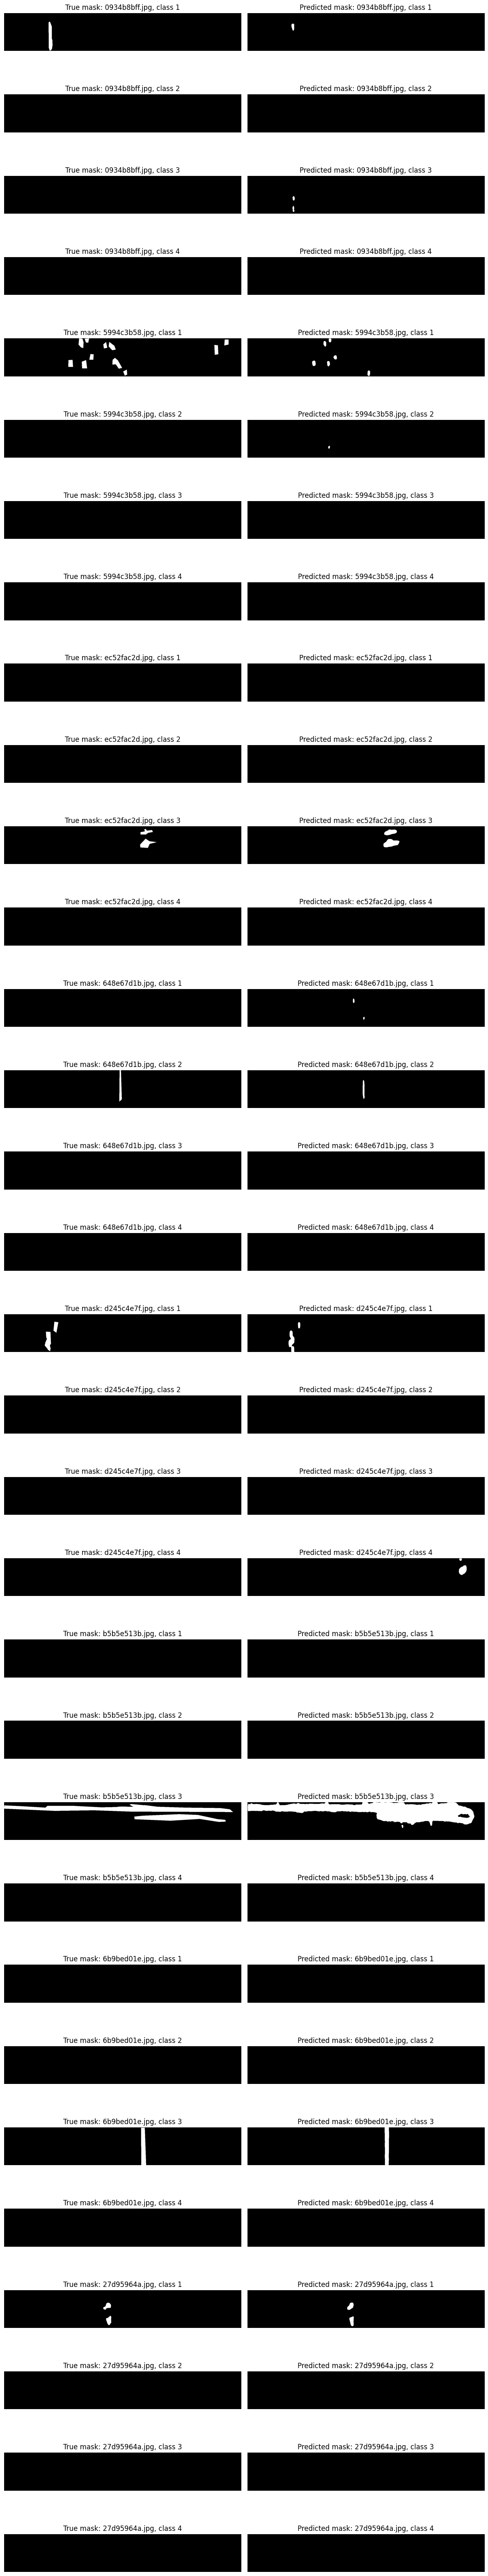

In [21]:
"""Визуализация  8 рандомных картинок"""
if __name__ == '__main__':
    import argparse

    parser = argparse.ArgumentParser(description="HW2: Severstal Steel Defect Detection")

    parser.add_argument('--train_csv', default='/content/drive/MyDrive/HW2_ML/train.csv')
    parser.add_argument('--test_csv', default='/content/drive/MyDrive/HW2_ML/sample_submission.csv')
    parser.add_argument('--test_dir', default='/content/drive/MyDrive/HW2_ML/test_images')
    parser.add_argument('--train_dir', default='/content/drive/MyDrive/HW2_ML/train_images')
    parser.add_argument('--out_csv', default='/content/drive/MyDrive/HW2_ML/submission.csv')
    parser.add_argument('--lr', type=float, default=3e-4)
    parser.add_argument('--batch_size', type=int, default=8)
    parser.add_argument('--val_size', type=int, default=0.2)
    parser.add_argument('--num_epochs', type=int, default=10)

    args = parser.parse_args(args=[])

    # main(args)
    # validation_test(args)
    visual_test(args)


In [ ]:
""""Вывод лоса и метрик во время обучение"""

if __name__ == '__main__':
    import argparse

    parser = argparse.ArgumentParser(description="HW2: Severstal Steel Defect Detection")

    parser.add_argument('--train_csv', default='/content/drive/MyDrive/HW2_ML/train.csv')
    parser.add_argument('--test_csv', default='/content/drive/MyDrive/HW2_ML/sample_submission.csv')
    parser.add_argument('--test_dir', default='/content/drive/MyDrive/HW2_ML/test_images')
    parser.add_argument('--train_dir', default='/content/drive/MyDrive/HW2_ML/train_images')
    parser.add_argument('--out_csv', default='/content/drive/MyDrive/HW2_ML/submission.csv')
    parser.add_argument('--lr', type=float, default=3e-4)
    parser.add_argument('--batch_size', type=int, default=8)
    parser.add_argument('--val_size', type=int, default=0.2)
    parser.add_argument('--num_epochs', type=int, default=10)

    args = parser.parse_args(args=[])

    main(args)
    # validation_test(args)
    # visual_test(args)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1, Batch 100, Avg Train Loss (last 100 batches): 0.1532
Epoch 1, Batch 200, Avg Train Loss (last 100 batches): 0.1495
Epoch 1, Batch 300, Avg Train Loss (last 100 batches): 0.1499
Epoch 1, Batch 400, Avg Train Loss (last 100 batches): 0.1526
Epoch 1, Batch 500, Avg Train Loss (last 100 batches): 0.1398
Epoch 1, Batch 600, Avg Train Loss (last 100 batches): 0.1431
Epoch 1/10, Train Loss: 0.1480, Val Mean Dice: 0.7526
Epoch 2, Batch 100, Avg Train Loss (last 100 batches): 0.1506
Epoch 2, Batch 200, Avg Train Loss (last 100 batches): 0.1625
Epoch 2, Batch 300, Avg Train Loss (last 100 batches): 0.1456
Epoch 2, Batch 400, Avg Train Loss (last 100 batches): 0.1391
Epoch 2, Batch 500, Avg Train Loss (last 100 batches): 0.1473
Epoch 2, Batch 600, Avg Train Loss (last 100 batches): 0.1345
Epoch 2/10, Train Loss: 0.1443, Val Mean Dice: 0.7853
Epoch 3, Batch 100, Avg Train Loss (last 100 batches): 0.1443
Epoch 3, Batch 200, Avg Train Loss (last 100 batches): 0.1427
Epoch 3, Batch 300, Avg 